# Analyzing COVID-19 Papers

In this challenge, we will continue with the topic of COVID pandemic, and focus on processing scientific papers on the subject. There is [CORD-19 Dataset](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge) with more than 7000 (at the time of writing) papers on COVID, available with metadata and abstracts (and for about half of them there is also full text provided).

A full example of analyzing this dataset using [Text Analytics for Health](https://docs.microsoft.com/azure/cognitive-services/text-analytics/how-tos/text-analytics-for-health/?WT.mc_id=academic-77958-bethanycheum) cognitive service is described [in this blog post](https://soshnikov.com/science/analyzing-medical-papers-with-azure-and-text-analytics-for-health/). We will discuss simplified version of this analysis.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Getting the Data

First, we need get the metadata for CORD papers that we will be working with.

**NOTE**: We do not provide a copy of the dataset as part of this repository. You may first need to download the [`metadata.csv`](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge?select=metadata.csv) file from [this dataset on Kaggle](https://www.kaggle.com/allen-institute-for-ai/CORD-19-research-challenge). Registration with Kaggle may be required. You may also download the dataset without registration [from here](https://ai2-semanticscholar-cord-19.s3-us-west-2.amazonaws.com/historical_releases.html), but it will include all full texts in addition to metadata file.

We will try to get the data directly from online source, however, if it fails, you need to download the data as described above. Also, it makes sense to download the data if you plan to experiment with it further, to save on waiting time.

> **NOTE** that dataset is quite large, around 1 Gb in size, and the following line of code can take a long time to complete! (~5 mins)

In [14]:
df = pd.read_csv("sample_data/metadata.csv",engine='python', on_bad_lines='skip')
# df = pd.read_csv("metadata.csv")
df.head()

,,,,,level and the degraded production level. Second,the economic loss metric represents the financial value associated with the reduced output. The contribution of this work revolves around the modeling of uncertainties triggered by new perturbations to interdependent economic sectors within an influenza pandemic timeline. We model the level of inoperability of economic sectors throughout their recovery horizon from the initial outbreak of the disaster using a dynamic model. Moreover,we use the level of inoperability values to quantify the cumulative economic losses incurred by the sectors within the recovery horizon. Finally,"we revisit the 2009 NCR pandemic scenario to demonstrate the use of uncertainty analysis in modeling the inoperability and economic loss behaviors due to time-varying perturbations and their associated ripple effects to interdependent economic sectors.""",2015-02-01,"El Haimar, Amine; Santos, Joost R.",Nat Hazards (Dordr),Unnamed: 7,Unnamed: 8,Unnamed: 9,document_parses/pdf_json/983ab625e029ff72163fbccc13345e6f6b18453f.json,document_parses/pmc_json/PMC7089399.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7089399/,Unnamed: 13
urmhw450,0f27bb160d422f07b8ca8687d1dac057df6a308f,PMC,Translation in plants-rules and exceptions,10.1007/bf00039382,PMC7089402,8980479,no-cc,Translation processes in plants are very simil...,1996,"Fütterer, Johannes; Hohn, Thomas",Plant Mol Biol,NaN,NaN,NaN,document_parses/pdf_json/0f27bb160d422f07b8ca8...,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
qua2hqch,NaN,PMC,"Handlungstheorie, Methoden, Arbeitssoziologie, Genera-tionssoziologie",10.1007/s11577-011-0137-2,PMC7089407,32214460,no-cc,NaN,2011-05-20,NaN,Kolner Z Soz Sozpsychol,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
rhgdorpb,228cb5b1ecc7afd5285874037b18a6541c6eb6df,PMC,Molecular Characterization of Three New Avian Infectious Bronchitis Virus (IBV) Strains Isolated in Quebec,10.1023/a:1020178326531,PMC7089411,12206312,no-cc,Three unrecognized field isolates of Infectiou...,2002,"Smati, Ridha; Silim, Amer; Guertin, Claude; He...",Virus Genes,NaN,NaN,NaN,document_parses/pdf_json/228cb5b1ecc7afd528587...,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
i1ph4upx,NaN,PMC,Proceedings of the Summer Scientific Meeting of the Faculty of Public Health Medicine 2015,10.1007/s11845-016-1509-4,PMC7089416,27830443,no-cc,NaN,2016-11-09,NaN,Ir J Med Sci,NaN,NaN,NaN,NaN,NaN,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN
udoioj4c,ecec7746daa9bd284d8a39e02fa351b9a3581c54,PMC,A two-step high-risk immunization based on high-risk immunization,10.1007/s11071-014-1555-2,PMC7089430,32214670,no-cc,"In this paper, the two-step high-risk immuniza...",2014-07-09,"Nian, Fuzhong; Wang, Ke",Nonlinear Dyn,NaN,NaN,NaN,document_parses/pdf_json/ecec7746daa9bd284d8a3...,document_parses/pmc_json/PMC7089430.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7...,NaN


In [15]:
print(df.columns.tolist())

['level and the degraded production level. Second', ' the economic loss metric represents the financial value associated with the reduced output. The contribution of this work revolves around the modeling of uncertainties triggered by new perturbations to interdependent economic sectors within an influenza pandemic timeline. We model the level of inoperability of economic sectors throughout their recovery horizon from the initial outbreak of the disaster using a dynamic model. Moreover', ' we use the level of inoperability values to quantify the cumulative economic losses incurred by the sectors within the recovery horizon. Finally', ' we revisit the 2009 NCR pandemic scenario to demonstrate the use of uncertainty analysis in modeling the inoperability and economic loss behaviors due to time-varying perturbations and their associated ripple effects to interdependent economic sectors."', '2015-02-01', 'El Haimar, Amine; Santos, Joost R.', 'Nat Hazards (Dordr)', 'Unnamed: 7', 'Unnamed: 8

In [16]:
df = pd.read_csv("metadata.csv", engine='python', on_bad_lines='skip', quoting=3)
print(df.columns.tolist()[:10])

['ted new risks', ' challenges and even opportunities. As a major contributor to economic stability', ' the insurance industry must follow these trends very closely and develop scenarios to anticipate these events."', '2021-01-01', '"von Overbeck', ' Jan"', 'Journal of insurance medicine', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9']


In [17]:
cols = ['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id',
        'license', 'abstract', 'publish_time', 'authors', 'journal',
        'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files',
        'pmc_json_files', 'url', 's2_id']

df = pd.read_csv("metadata.csv", engine='python', on_bad_lines='skip',
                 names=cols, skiprows=1)
print(df.columns.tolist())
print(df.shape)
df.head()

['cord_uid', 'sha', 'source_x', 'title', 'doi', 'pmcid', 'pubmed_id', 'license', 'abstract', 'publish_time', 'authors', 'journal', 'mag_id', 'who_covidence_id', 'arxiv_id', 'pdf_json_files', 'pmc_json_files', 'url', 's2_id']
(410938, 19)


,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,bioj0s05,NaN,Medline,COVID-19 and obesity.,10.23736/s1121-421x.20.02748-8,NaN,32677421.0,unk,NaN,2020-07-16,"Devecchi, Andrea; Ippolito, Mirko; Merlo, Fabi...",Minerva gastroenterologica e dietologica,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.23736/s1121-421x.20.02748-8...,220608249.0
1,b4gnzz4h,NaN,Medline,Moving pictures: Reassessing docking experimen...,10.1002/prot.26152,NaN,34038009.0,unk,The modeling of protein assemblies at the atom...,2021-05-26,"Prévost, Chantal; Sacquin-Mora, Sophie",Proteins,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1002/prot.26152; https://ww...,235197915.0
2,7df5nsev,NaN,Medline,Lessons from a decade of emerging diseases: to...,10.4103/2224-3151.122933,NaN,28612762.0,unk,NaN,2013,"Brown, Richard",WHO South-East Asia journal of public health,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.4103/2224-3151.122933; http...,41701605.0
3,4xo4t4gb,NaN,Medline,Connecting with Families through Virtual Perin...,10.1097/nmc.0000000000000665,NaN,32956169.0,unk,The COVID-19 pandemic has caused many changes ...,2020-09-11,"Pasadino, Francine; DeMarco, Kathleen; Lampert...",MCN. The American journal of maternal child nu...,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1097/nmc.0000000000000665; ...,221843553.0
4,g9zf0214,NaN,Medline,Optimal Timing for Laparoscopic Cholecystectom...,10.1177/1457496917748224,NaN,29277136.0,unk,BACKGROUND AND AIMS Endoscopic retrograde chol...,2018,"Friis, C; Rothman, J P; Burcharth, J; Rosenber...",Scandinavian journal of surgery : SJS : offici...,NaN,NaN,NaN,NaN,NaN,https://doi.org/10.1177/1457496917748224; http...,29149737.0


We will now convert publication date column to `datetime`, and plot the histogram to see the range of publication dates.

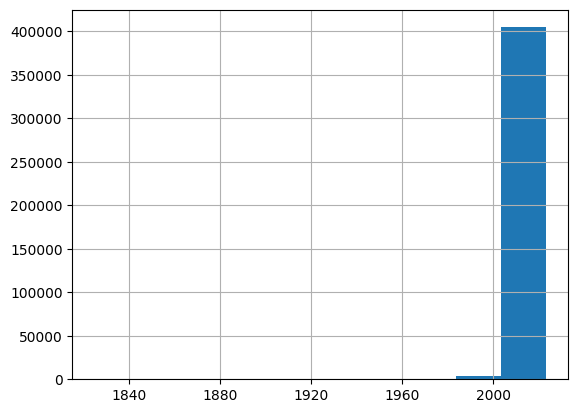

In [19]:
df['publish_time'] = pd.to_datetime(df['publish_time'],format='mixed', errors='coerce')
df['publish_time'].hist()
plt.show()

Interestingly, there are coronavirus-related papers that date back to 1880!

## Structured Data Extraction

Let's see what kind of information we can easily extract from abstracts. One thing we might be interested in is to see which treatment strategies exist, and how they evolved over time. To begin with, we can manually compile the list of possible medications used to treat COVID, and also the list of diagnoses. We then go over them and search corresponding terms in the abstracts of papers.

In [20]:
medications = [
    'hydroxychloroquine', 'chloroquine', 'tocilizumab', 'remdesivir', 'azithromycin',
    'lopinavir', 'ritonavir', 'dexamethasone', 'heparin', 'favipiravir', 'methylprednisolone']
diagnosis = [
    'covid','sars','pneumonia','infection','diabetes','coronavirus','death'
]

for m in medications:
    print(f" + Processing medication: {m}")
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))

for m in diagnosis:
    print(f" + Processing diagnosis: {m}")
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))

 + Processing medication: hydroxychloroquine
 + Processing medication: chloroquine
 + Processing medication: tocilizumab
 + Processing medication: remdesivir
 + Processing medication: azithromycin
 + Processing medication: lopinavir
 + Processing medication: ritonavir
 + Processing medication: dexamethasone
 + Processing medication: heparin
 + Processing medication: favipiravir
 + Processing medication: methylprednisolone
 + Processing diagnosis: covid
 + Processing diagnosis: sars
 + Processing diagnosis: pneumonia
 + Processing diagnosis: infection
 + Processing diagnosis: diabetes
 + Processing diagnosis: coronavirus
 + Processing diagnosis: death


We have added a bunch of columns to our dataframe that contain number of times a given medicine/diagnosis is present in the abstract.

> **Note** that we add space to the beginning of the word when looking for a substring. If we do not do that, we might get wrong results, because *chloroquine* would also be found inside substring *hydroxychloroquine*. Also, we force conversion of abstracts column to `str` to get rid of an error - try removing `str` and see what happens.

To make working with data easier, we can extract the sub-frame with only medication counts, and compute the accumulated number of occurrences. This gives is the most popular medication:

In [21]:
dfm = df[medications]
dfm = dfm.sum().reset_index().rename(columns={ 'index' : 'Name', 0 : 'Count'})
dfm.sort_values('Count',ascending=False)

,Name,Count
0,hydroxychloroquine,4863
3,remdesivir,4014
2,tocilizumab,3080
1,chloroquine,2305
8,heparin,1974
5,lopinavir,1969
7,dexamethasone,1805
4,azithromycin,1697
9,favipiravir,1409
10,methylprednisolone,884


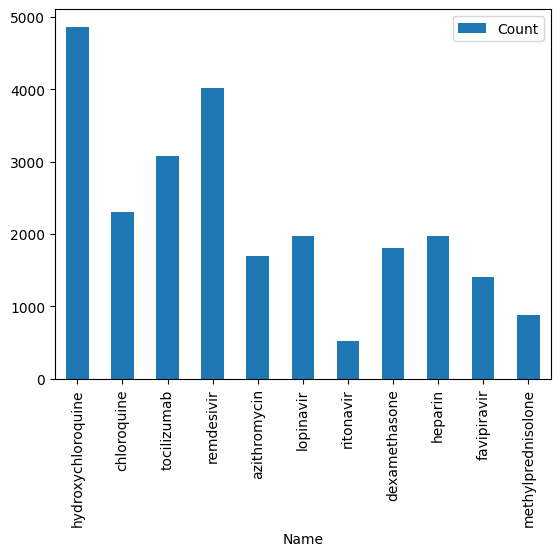

In [22]:
dfm.set_index('Name').plot(kind='bar')
plt.show()

## Looking for Trends in Treatment Strategy

In the example above we have `sum`ed all values, but we can also do the same on a monthly basis:

In [23]:
dfm = df[['publish_time']+medications].set_index('publish_time')
dfm = dfm[(dfm.index>="2020-01-01") & (dfm.index<="2021-07-31")]
dfmt = dfm.groupby([dfm.index.year,dfm.index.month]).sum()
dfmt

hydroxychloroquine  chloroquine  tocilizumab  \
publish_time publish_time                                                 
2020         1                           2791         1493         1386   
             2                              0            0            0   
             3                              2           15            0   
             4                             24           56            1   
             5                             22            4            9   
             6                             15           11            6   
             7                             28            7            5   
             8                             17            9            4   
             9                             16           13            3   
             10                             7            2            3   
             11                            19            7            4   
             12                            17           13            5   
2021         1                           1715          567         1430   
             2                             10            0            2   
             3                             20            5           31   
             4                             10            5            6   
             5                              2            5            1   
             6                              7            4            8   
             7                             13            3           22   

                           remdesivir  azithromycin  lopinavir  ritonavir  \
publish_time publish_time                                                   
2020         1                   1635           859       1185        317   
             2                      0             0          3          0   
             3                      7             1          2          3   
             4                     19             5          8          0   
             5                      5             2          9         11   
             6                     20            10          4          2   
             7                     26             8         13          4   
             8                      9            13         17          1   
             9                     21             5          4          1   
             10                     3            23          5          0   
             11                     9             3          6          2   
             12                    34             4          6          0   
2021         1                   1886           670        616        159   
             2                      2             6          1          0   
             3                     27            12         17          3   
             4                      6             5          1          2   
             5                      4             6          2          2   
             6                      7             5          5          0   
             7                     19             6          4          1   

                           dexamethasone  heparin  favipiravir  \
publish_time publish_time                                        
2020         1                       437      732          545   
             2                         0        0            0   
             3                         0        3            0   
             4                         3        8           31   
             5                         2        5            1   
             6                         7        4            1   
             7                         2        5            7   
             8                        12        0            3   
             9                        13       18            2   
             10                       15       18            1   
             11                        1 

This gives us a good picture of treatment strategies. Let's visualize it!

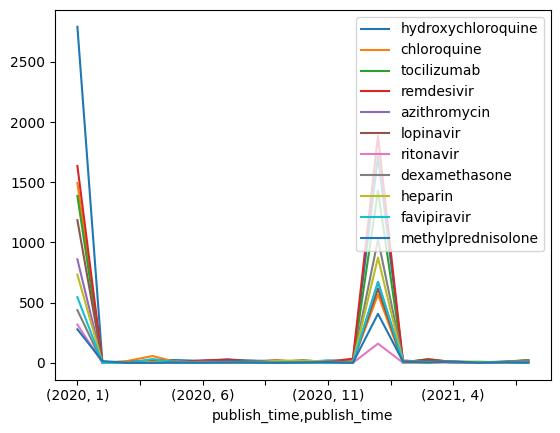

In [24]:
dfmt.plot()
plt.show()

An interesting observation is that we have huge spikes at two locations: January, 2020 and January, 2021. It is caused by the fact that some papers do not have a clearly specified data of publication, and they are specified as January of the respective year.

To make more sense of the data, let's visualize just a few medicines. We will also "erase" data for January, and fill it in by some medium value, in order to make nicer plot:

/tmp/ipykernel_791/1877372667.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dfmt.fillna(method='pad',inplace=True)


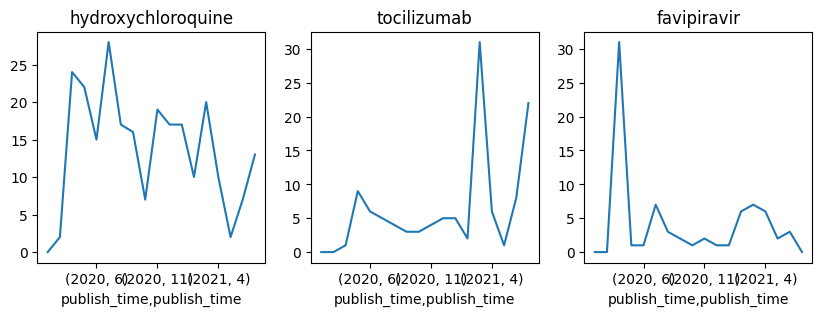

In [25]:
meds = ['hydroxychloroquine','tocilizumab','favipiravir']
dfmt.loc[(2020,1)] = np.nan
dfmt.loc[(2021,1)] = np.nan
dfmt.fillna(method='pad',inplace=True)
fig, ax = plt.subplots(1,len(meds),figsize=(10,3))
for i,m in enumerate(meds):
    dfmt[m].plot(ax=ax[i])
    ax[i].set_title(m)
plt.show()

Observe how popularity of hydroxychloroquine was on the rise in the first few months, and then started to decline, while number of mentions of favipiravir shows stable rise. Another good way to visualize relative popularity is to use **stack plot** (or **area plot** in Pandas terminology):

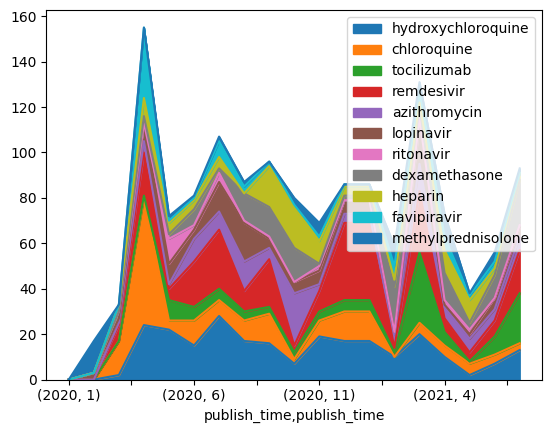

In [26]:
dfmt.plot.area()
plt.show()

Even further, we can compute relative popularity in percents:

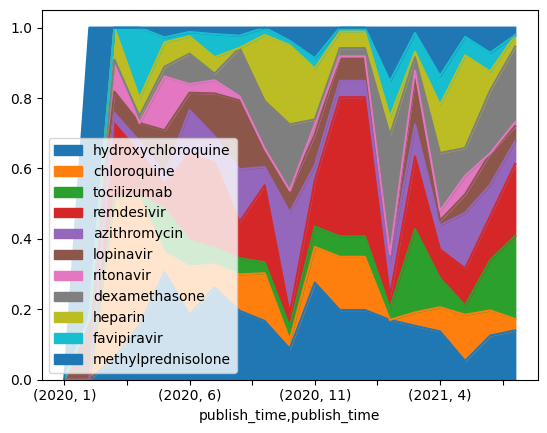

In [27]:
dfmtp = dfmt.iloc[:,:].apply(lambda x: x/x.sum(), axis=1)
dfmtp.plot.area()
plt.show()


## Computing Medicine-Diagnosis Correspondence

One of the most interesting relationships we can look for is how different diagnoses are treated with different medicines. In order to visualize it, we need to compute **co-occurence frequency map**, which would show how many times two terms are mentioned in the same paper.

Such a map is essentially a 2D matrix, which is best represented by **numpy array**. We will compute this map by walking through all abstracts, and marking entities that occur there:

In [28]:
m = np.zeros((len(medications),len(diagnosis)))
for a in df['abstract']:
    x = str(a).lower()
    for i,d in enumerate(diagnosis):
        if ' '+d in x:
            for j,me in enumerate(medications):
                if ' '+me in x:
                    m[j,i] += 1

In [29]:
m

array([[2441., 1145.,  379., 1080.,  168., 1406.,  445.],
       [1114.,  639.,  127.,  464.,   39.,  753.,  168.],
       [1124.,  410.,  352.,  552.,   98.,  527.,  262.],
       [1704., 1096.,  299.,  833.,   83., 1069.,  290.],
       [ 929.,  416.,  206.,  451.,   81.,  468.,  192.],
       [ 999.,  562.,  203.,  442.,   53.,  681.,  177.],
       [ 278.,  190.,   42.,  142.,   10.,  190.,   56.],
       [ 831.,  367.,  196.,  421.,   59.,  391.,  188.],
       [ 805.,  344.,  186.,  388.,   53.,  389.,  127.],
       [ 547.,  334.,  110.,  248.,   26.,  351.,   78.],
       [ 383.,  214.,  148.,  225.,   40.,  213.,   89.]])

One of the ways to visualize this matrix is to draw a **heatmap**:

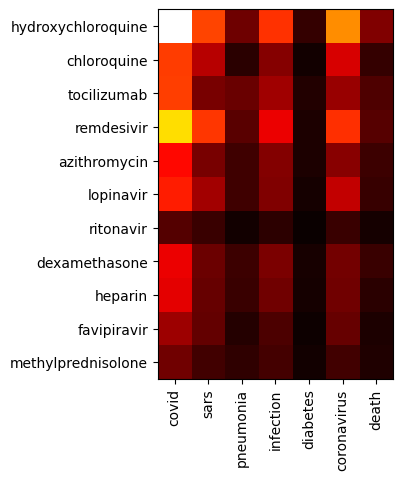

In [30]:
plt.imshow(m,interpolation='nearest',cmap='hot')
ax = plt.gca()
ax.set_yticks(range(len(medications)))
ax.set_yticklabels(medications)
ax.set_xticks(range(len(diagnosis)))
ax.set_xticklabels(diagnosis,rotation=90)
plt.show()

However, even better visualization can be done using so-called **Sankey** diagram! `matplotlib` does not have built-in support for this diagram type, so we would have to use [Plotly](https://plotly.com/python/) as described [in this tutorial](https://plotly.com/python/sankey-diagram/).

To make plotly sankey diagram, we need to build the following lists:
* List `all_nodes` of all nodes in the graph, which will include both medications and diagnosis
* List of source and target indices - those lists would show, which nodes go to the left, and which to the right part of the diagram
* List of all links, each link consisting of:
   - Source index in the `all_nodes` array
   - Target index
   - Value indicating strength of the link. This is exactly the value from our co-occurence matrix.
   - Optionally color of the link. We will make an option to highlight some of the terms for clarity

Generic code to draw sankey diagram is structured as a separate `sankey` function, which takes two lists (source and target categories) and co-occurence matrix. It also allows us to specify the threshold, and omit all links that are weaker than that threshold - this makes the diagram a little bit less complex.

In [31]:
import plotly.graph_objects as go

def sankey(cat1, cat2, m, treshold=0, h1=[], h2=[]):
    all_nodes = cat1 + cat2
    source_indices = list(range(len(cat1)))
    target_indices = list(range(len(cat1),len(cat1)+len(cat2)))

    s, t, v, c = [], [], [], []
    for i in range(len(cat1)):
        for j in range(len(cat2)):
            if m[i,j]>treshold:
                s.append(i)
                t.append(len(cat1)+j)
                v.append(m[i,j])
                c.append('pink' if i in h1 or j in h2 else 'lightgray')

    fig = go.Figure(data=[go.Sankey(
        # Define nodes
        node = dict(
        pad = 40,
        thickness = 40,
        line = dict(color = "black", width = 1.0),
        label =  all_nodes),

        # Add links
        link = dict(
        source =  s,
        target =  t,
        value =  v,
        color = c
    ))])
    fig.show()

sankey(medications,diagnosis,m,500,h2=[0])

## Conclusion

You have seen that we can use quite simple methods to extract information from non-structured data sources, such as text. In this example, we have taken the existing list of medications, but it would be much more powerful to use natural language processing (NLP) techniques to perform entity extraction from text. In [this blog post](https://soshnikov.com/science/analyzing-medical-papers-with-azure-and-text-analytics-for-health/) we describe how to use cloud services for entity extraction. Another option would be using Python NLP libraries such as [NLTK](https://www.nltk.org/) - an approach for extracting information from text using NLTK is described [here](https://www.nltk.org/book/ch07.html).

## Challenge

Continue to research the COVID paper data along the following lines:

1. Build co-occurrence matrix of different medications, and see which medications often occur together (i.e. mentioned in one abstract). You can modify the code for building co-occurrence matrix for medications and diagnoses.
1. Visualize this matrix using heatmap.
1. As a stretch goal, you may want to visualize the co-occurrence of medications using [chord diagram](https://en.wikipedia.org/wiki/Chord_diagram). [This library](https://pypi.org/project/chord/) may help you draw a chord diagram.
1. As another stretch goal, try to extract dosages of different medications (such as **400mg** in *take 400mg of chloroquine daily*) using regular expressions, and build dataframe that shows different dosages for different medications. **Note**: consider numeric values that are in close textual vicinity of the medicine name.

In [32]:
# Task 1: Co-occurrence matrix for medications
medications = ['hydroxychloroquine', 'chloroquine', 'remdesivir', 'dexamethasone',
               'azithromycin', 'lopinavir', 'ritonavir', 'heparin',
               'favipiravir', 'methylprednisolone']

# Build medication occurrence columns
for med in medications:
    df[med] = df['abstract'].str.contains(' '+med, case=False, na=False).astype(int)

# Build co-occurrence matrix
co_matrix = pd.DataFrame(index=medications, columns=medications, data=0)

for i, med1 in enumerate(medications):
    for j, med2 in enumerate(medications):
        co_matrix.loc[med1, med2] = (df[med1] & df[med2]).sum()

print(co_matrix)

                    hydroxychloroquine  chloroquine  remdesivir  \
hydroxychloroquine                2778          770         537   
chloroquine                        770         1324         357   
remdesivir                         537          357        2023   
dexamethasone                      137           58         317   
azithromycin                       701          245         178   
lopinavir                          527          303         405   
ritonavir                          133           92         105   
heparin                             64           18          55   
favipiravir                        251          152         302   
methylprednisolone                  45            6          38   

                    dexamethasone  azithromycin  lopinavir  ritonavir  \
hydroxychloroquine            137           701        527        133   
chloroquine                    58           245        303         92   
remdesivir                    317          

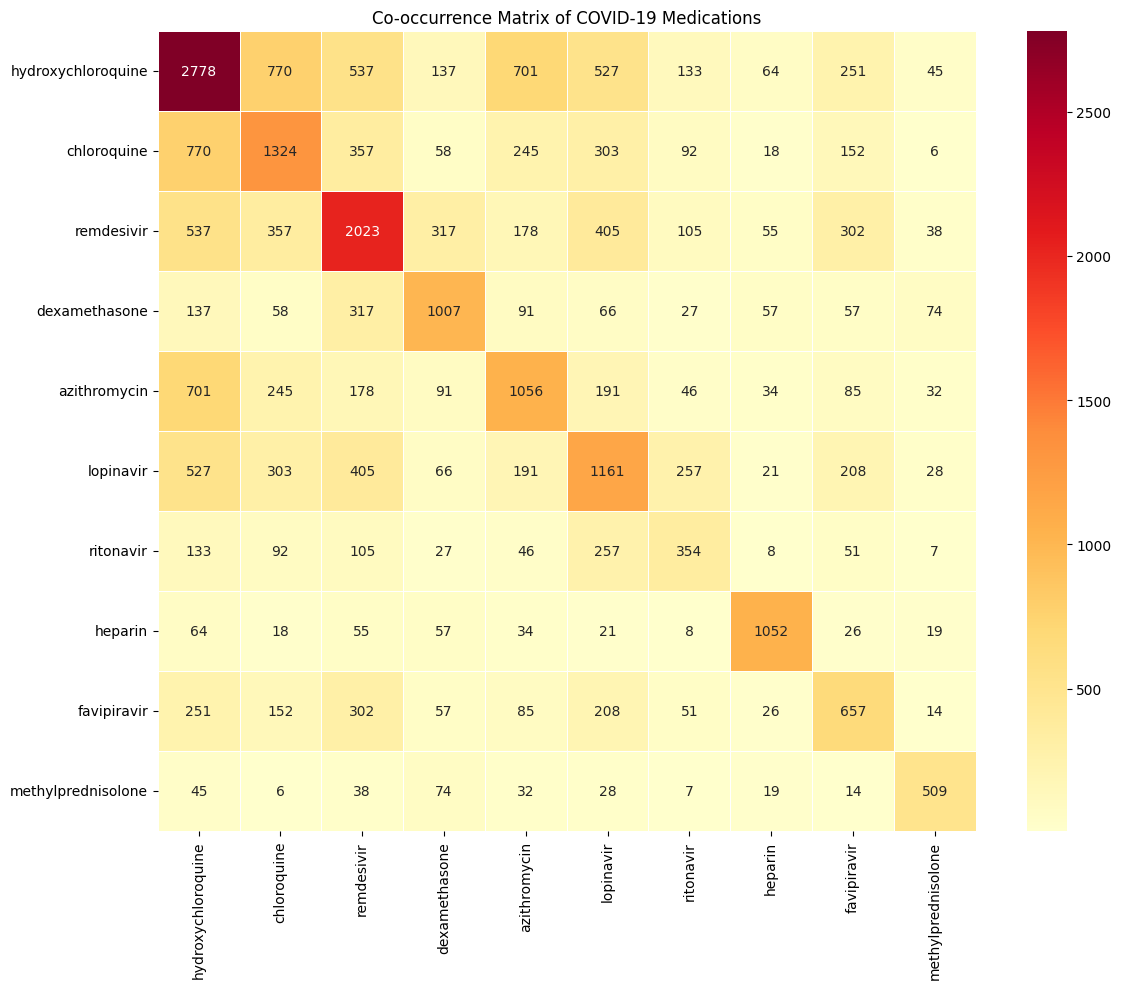

In [33]:
# Task 2: Heatmap visualization
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix.astype(int),
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Co-occurrence Matrix of COVID-19 Medications')
plt.tight_layout()
plt.show()

In [34]:
!pip install chord

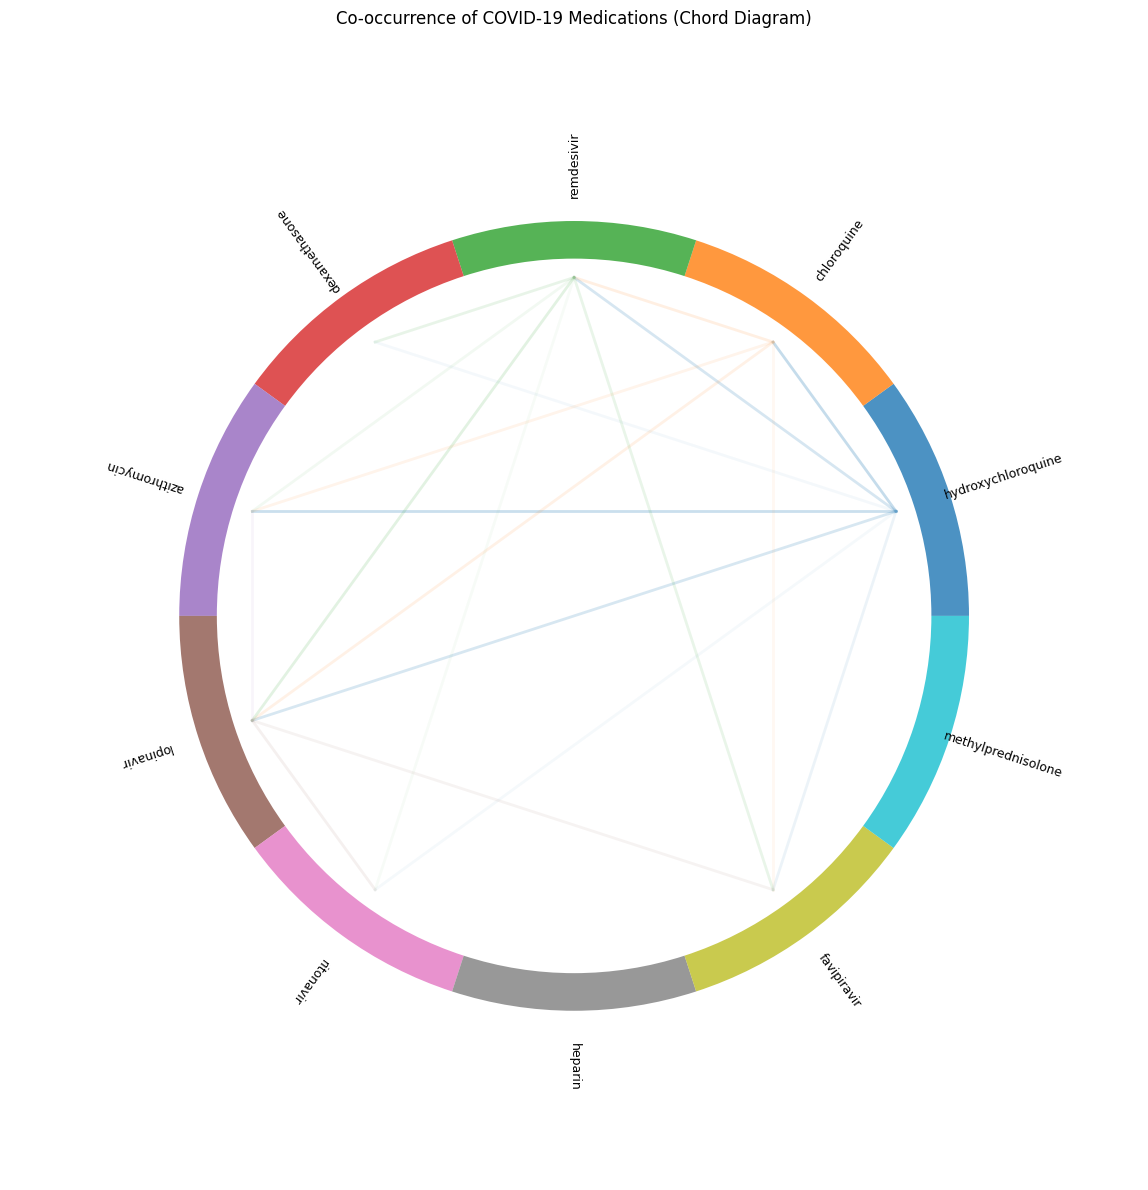

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 简化版chord diagram用circos风格
matrix = co_matrix.astype(int).values
n = len(medications)
colors = plt.cm.tab10(np.linspace(0, 1, n))

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))

# 画每个药物的arc
angles = np.linspace(0, 2*np.pi, n+1)

for i in range(n):
    ax.barh(1, angles[i+1]-angles[i], left=angles[i],
            height=0.1, color=colors[i], alpha=0.8)

# 画连接线
for i in range(n):
    for j in range(i+1, n):
        if matrix[i][j] > 100:  # 只画出现次数超过100的
            angle_i = (angles[i] + angles[i+1]) / 2
            angle_j = (angles[j] + angles[j+1]) / 2
            ax.plot([angle_i, angle_j], [0.9, 0.9],
                   color=colors[i], alpha=matrix[i][j]/3000, linewidth=2)

# 加标签
for i in range(n):
    angle = (angles[i] + angles[i+1]) / 2
    ax.text(angle, 1.2, medications[i],
            ha='center', va='center', fontsize=9, rotation=np.degrees(angle))

ax.set_ylim(0, 1.5)
ax.axis('off')
plt.title('Co-occurrence of COVID-19 Medications (Chord Diagram)', pad=20)
plt.tight_layout()
plt.show()

In [38]:
import re

dosage_data = []

for _, row in df.iterrows():
    abstract = str(row['abstract'])
    for med in medications:
        if med.lower() in abstract.lower():
            # Find all dosages in the abstract
            dosages = re.findall(r'\d+\.?\d*\s*(?:mg|g|mcg)', abstract, re.IGNORECASE)
            for dosage in dosages:
                dosage_data.append({'medication': med, 'dosage': dosage.strip()})

dosage_df = pd.DataFrame(dosage_data)
print(dosage_df.shape)
dosage_df.head(20)

(5620, 2)


,medication,dosage
0,heparin,4 g
1,dexamethasone,2 g
2,hydroxychloroquine,19. G
3,chloroquine,19. G
4,remdesivir,19. G
5,azithromycin,19. G
6,methylprednisolone,20 mg
7,heparin,5 mg
8,heparin,12 g
9,dexamethasone,20 mg


In [39]:
# 整理成每个药的dosage summary
dosage_summary = dosage_df.groupby('medication')['dosage'].apply(list).reset_index()

# 找每个药最常见的dosage
dosage_common = dosage_df.groupby(['medication', 'dosage']).size().reset_index(name='count')
dosage_common = dosage_common.sort_values(['medication', 'count'], ascending=[True, False])

# 每个药取top 5 dosage
top_dosages = dosage_common.groupby('medication').head(5)
print(top_dosages.to_string())

              medication   dosage  count
114         azithromycin   500 mg     52
96          azithromycin   400 mg     31
51          azithromycin   200 mg     26
12          azithromycin      1 g     21
18          azithromycin   100 mg     20
291          chloroquine   400 mg    153
230          chloroquine   200 mg    110
309          chloroquine   500 mg     60
184          chloroquine   100 mg     39
355          chloroquine   800 mg     35
525        dexamethasone     6 mg     63
453        dexamethasone    20 mg     28
447        dexamethasone      2 g     26
399        dexamethasone    10 mg     22
546        dexamethasone     8 mg     22
636          favipiravir   800 mg     17
620          favipiravir    400mg     16
628          favipiravir   600 mg     15
583          favipiravir  1800 mg     14
591          favipiravir      2 g     13
723              heparin    40 mg     18
729              heparin     5 mg     15
751              heparin    60 mg     12
687             